In [1]:
import xarray as xr
import healpy as hp
import os
from matplotlib import pyplot as plt
from aqua.core.graphics import plot_single_map

/opt/homebrew/Caskroom/miniconda/base/envs/aqua-dev/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
catalog = 'climatedt-phase1'
model = 'IFS-NEMO'
exp = 'historical-1990'
year = 2000

In [3]:
index = xr.open_mfdataset(f'ETCCDI.SDII.{catalog}.{model}.{exp}.{year}.nc')

2026-02-19 21:38:24 :: plot_single_map :: INFO     -> Input data is in HEALPix format with nside=1024.


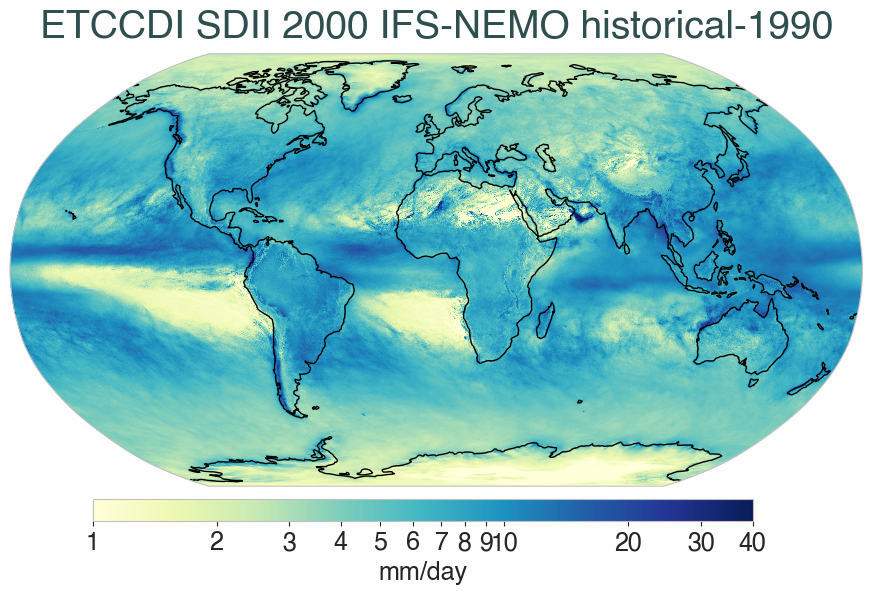

In [28]:
from matplotlib.colors import LogNorm
from matplotlib.colorbar import Colorbar

index = index.fillna(1.0)
title = f'ETCCDI SDII {year} {model} {exp}'
norm = LogNorm(vmin=1.0, vmax=40.0)
fig, ax = plot_single_map(index.tprate, title=title, title_size=28,
cmap='YlGnBu', vmin=1.0, vmax=40.0, loglevel='INFO', return_fig=True, contour=False, norm=norm, cbar=False)

# Add colorbar with minimal gap to the map
cbar_ax = fig.add_axes([0.2, 0.2, 0.6, 0.025])
cbar = Colorbar(ax=cbar_ax, mappable=ax.collections[0], norm=norm, cmap='YlGnBu', orientation='horizontal')
cbar.set_ticks([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 20, 30, 40])
cbar.set_ticklabels(['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '20', '30', '40'])
cbar.ax.tick_params(labelsize=18)
cbar.set_label('mm/day', fontsize=18)

fig.savefig(f'ETCCDI_SDII_{catalog}_{model}_{exp}_{year}.png', dpi=600, bbox_inches='tight')

In [5]:
fig